# Per-Finger Touch Detection Model (1D CNN & MLP in PyTorch)

This notebook implements optimized **1D CNN** and **MLP** architectures for ultra-short 4-step sequence windows ($4 \text{ timesteps} \times 8 \text{ velocity features} = 32 \text{ input dimensions}$).

## Why 1D CNN / MLP for SEQ_LEN = 4?
LSTMs are engineered for long temporal dependencies. For sequence length 4, recurrent gating adds unneeded complexity. 
- **1D CNN**: Captures local temporal transition kernels across the 4 timesteps.
- **MLP**: Flattens the 32 input parameters directly into dense non-linear representation layers.

## 1. Imports & Hyperparameters Setup

In [19]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Set random seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Hyperparameters
SEQ_LEN = 4          # 4 velocity transition steps
FEATURE_DIM = 8      # 2 wrist vels + 6 finger joint vels
FLATTENED_DIM = SEQ_LEN * FEATURE_DIM  # 32 total features
BATCH_SIZE = 32
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
EPOCHS = 40

# Setup device agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Load & Normalize CSV Datasets (`training_data.csv` & `test_data.csv`)

In [20]:
def extract_features_and_labels(csv_path):
    df = pd.read_csv(csv_path)
    
    vel_cols_step = []
    for v in range(1, 5):
        cols = [
            f"wrist{v}_vx", f"wrist{v}_vy",
            f"mcp{v}_vx", f"mcp{v}_vy",
            f"pip{v}_vx", f"pip{v}_vy",
            f"dip{v}_vx", f"dip{v}_vy"
        ]
        vel_cols_step.append(cols)
        
    n_samples = len(df)
    X = np.zeros((n_samples, 4, 8), dtype=np.float32)
    
    for step_idx in range(4):
        cols = vel_cols_step[step_idx]
        X[:, step_idx, :] = df[cols].fillna(0.0).values.astype(np.float32)
        
    target_col = "touch_finger" if "touch_finger" in df.columns else "touch"
    y = df[target_col].astype(str).str.strip().str.lower().isin(["1", "true", "t", "yes", "y"]).values.astype(np.float32)
    y = y.reshape(-1, 1)
    
    return X, y

TRAIN_CSV = "./data/training_data.csv"
TEST_CSV = "./data/test_data.csv"

X_train_np, y_train_np = extract_features_and_labels(TRAIN_CSV)
X_test_np, y_test_np = extract_features_and_labels(TEST_CSV)

# Normalize features across 32 dimensions using StandardScaler
scaler = StandardScaler()
N_train, T, C = X_train_np.shape
N_test, _, _ = X_test_np.shape

X_train_flat = X_train_np.reshape(N_train, -1)
X_test_flat = X_test_np.reshape(N_test, -1)

X_train_scaled = scaler.fit_transform(X_train_flat).reshape(N_train, T, C)
X_test_scaled = scaler.transform(X_test_flat).reshape(N_test, T, C)

# PyTorch Tensors
X_train = torch.from_numpy(X_train_scaled).type(torch.float32)
y_train = torch.from_numpy(y_train_np).type(torch.float32)
X_test = torch.from_numpy(X_test_scaled).type(torch.float32)
y_test = torch.from_numpy(y_test_np).type(torch.float32)

print(f"Normalized X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Normalized X_test shape:  {X_test.shape},  y_test shape:  {y_test.shape}")

Normalized X_train shape: torch.Size([1791, 4, 8]), y_train shape: torch.Size([1791, 1])
Normalized X_test shape:  torch.Size([315, 4, 8]),  y_test shape:  torch.Size([315, 1])


## 3. PyTorch Dataset and DataLoader

In [21]:
class VelocitySequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = VelocitySequenceDataset(X_train, y_train)
test_dataset = VelocitySequenceDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 4. Building the 1D CNN Model Architecture

The **1D CNN** treats the 8 velocity components as input channels (`in_channels=8`) across sequence length `4` (`length=4`).

In [22]:
class FingerTouch1DCNN(nn.Module):
    def __init__(self, in_channels: int = 8, seq_len: int = 4, dropout: float = 0.25):
        super().__init__()
        
        # 1D Convolutional Blocks (channels = 8 -> 32 -> 64)
        self.conv_block1 = nn.Sequential(
            nn.Conv1d(in_channels=in_channels, out_channels=32, kernel_size=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)  # Pools across temporal dimension to 1 value per channel
        )
        
        # Dense Classifier Head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        # Input x shape: (batch_size, seq_len, in_channels) = (batch_size, 4, 8)
        # Permute for Conv1d: (batch_size, in_channels, seq_len) = (batch_size, 8, 4)
        x_conv = x.permute(0, 2, 1)
        
        out = self.conv_block1(x_conv)
        out = self.conv_block2(out)
        logits = self.classifier(out)
        return logits

model_cnn = FingerTouch1DCNN(in_channels=FEATURE_DIM, seq_len=SEQ_LEN).to(device)
print(model_cnn)

FingerTouch1DCNN(
  (conv_block1): Sequential(
    (0): Conv1d(8, 32, kernel_size=(2,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(2,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 5. Building Alternative MLP Model Architecture

The **MLP** flattens the 4 steps $\times$ 8 features into a single 32-dimensional input vector.

In [23]:
class FingerTouchMLP(nn.Module):
    def __init__(self, input_dim: int = 32, dropout: float = 0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.net(x)

model_mlp = FingerTouchMLP(input_dim=FLATTENED_DIM).to(device)
print(model_mlp)

FingerTouchMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32, out_features=64, bias=True)
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.25, inplace=False)
    (5): Linear(in_features=64, out_features=32, bias=True)
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.25, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 6. Training & Evaluation Helper Function

In [24]:
def train_and_evaluate(model, train_loader, test_loader, epochs=30, lr=0.001, weight_decay=1e-4):
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    def accuracy_fn(y_true, y_pred):
        return (torch.eq(y_true, y_pred).sum().item() / len(y_pred)) * 100.0
        
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []
    best_test_loss = float('inf')
    
    for epoch in range(1, epochs + 1):
        model.train()
        t_loss, t_acc = 0.0, 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            
            logits = model(X_b)
            loss = loss_fn(logits, y_b)
            preds = torch.round(torch.sigmoid(logits))
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            t_loss += loss.item() * len(X_b)
            t_acc += (accuracy_fn(y_b, preds) / 100.0) * len(X_b)
            
        train_loss = t_loss / len(train_loader.dataset)
        train_acc = (t_acc / len(train_loader.dataset)) * 100.0
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Eval
        model.eval()
        v_loss, v_acc = 0.0, 0.0
        with torch.inference_mode():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                logits = model(X_b)
                loss = loss_fn(logits, y_b)
                preds = torch.round(torch.sigmoid(logits))
                
                v_loss += loss.item() * len(X_b)
                v_acc += (accuracy_fn(y_b, preds) / 100.0) * len(X_b)
                
        test_loss = v_loss / len(test_loader.dataset)
        test_acc = (v_acc / len(test_loader.dataset)) * 100.0
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        
        scheduler.step(test_loss)
        
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch: {epoch:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
            
    return train_losses, test_losses, train_accs, test_accs

## 7. Training 1D CNN Model

In [25]:
print("=== Training 1D CNN Model ===")
cnn_train_loss, cnn_test_loss, cnn_train_acc, cnn_test_acc = train_and_evaluate(
    model=model_cnn,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

=== Training 1D CNN Model ===
Epoch: 01 | Train Loss: 0.5957 | Train Acc: 72.19% | Test Loss: 0.4472 | Test Acc: 82.86%
Epoch: 05 | Train Loss: 0.3138 | Train Acc: 88.11% | Test Loss: 0.2849 | Test Acc: 90.48%
Epoch: 10 | Train Loss: 0.2782 | Train Acc: 88.89% | Test Loss: 0.2543 | Test Acc: 92.06%
Epoch: 15 | Train Loss: 0.2942 | Train Acc: 89.17% | Test Loss: 0.2537 | Test Acc: 91.11%
Epoch: 20 | Train Loss: 0.2736 | Train Acc: 88.83% | Test Loss: 0.2369 | Test Acc: 91.75%
Epoch: 25 | Train Loss: 0.2683 | Train Acc: 88.89% | Test Loss: 0.2351 | Test Acc: 91.11%
Epoch: 30 | Train Loss: 0.2616 | Train Acc: 89.84% | Test Loss: 0.2320 | Test Acc: 93.02%
Epoch: 35 | Train Loss: 0.2587 | Train Acc: 89.78% | Test Loss: 0.2326 | Test Acc: 91.75%
Epoch: 40 | Train Loss: 0.2588 | Train Acc: 89.84% | Test Loss: 0.2261 | Test Acc: 92.70%


## 8. Training MLP Model

In [10]:
print("\n=== Training MLP Model ===")
mlp_train_loss, mlp_test_loss, mlp_train_acc, mlp_test_acc = train_and_evaluate(
    model=model_mlp,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


=== Training MLP Model ===
Epoch: 01 | Train Loss: 0.6131 | Train Acc: 68.18% | Test Loss: 0.5406 | Test Acc: 72.83%
Epoch: 05 | Train Loss: 0.4347 | Train Acc: 82.03% | Test Loss: 0.3971 | Test Acc: 82.66%
Epoch: 10 | Train Loss: 0.3726 | Train Acc: 85.54% | Test Loss: 0.3710 | Test Acc: 84.68%
Epoch: 15 | Train Loss: 0.3643 | Train Acc: 85.13% | Test Loss: 0.3668 | Test Acc: 84.68%
Epoch: 20 | Train Loss: 0.3243 | Train Acc: 86.86% | Test Loss: 0.3631 | Test Acc: 84.39%
Epoch: 25 | Train Loss: 0.3344 | Train Acc: 86.66% | Test Loss: 0.3716 | Test Acc: 82.95%
Epoch: 30 | Train Loss: 0.3240 | Train Acc: 87.47% | Test Loss: 0.3505 | Test Acc: 84.68%
Epoch: 35 | Train Loss: 0.3138 | Train Acc: 87.68% | Test Loss: 0.3490 | Test Acc: 84.68%
Epoch: 40 | Train Loss: 0.2986 | Train Acc: 88.49% | Test Loss: 0.3420 | Test Acc: 86.13%


## 9. Plotting 1D CNN vs MLP Accuracy Comparison

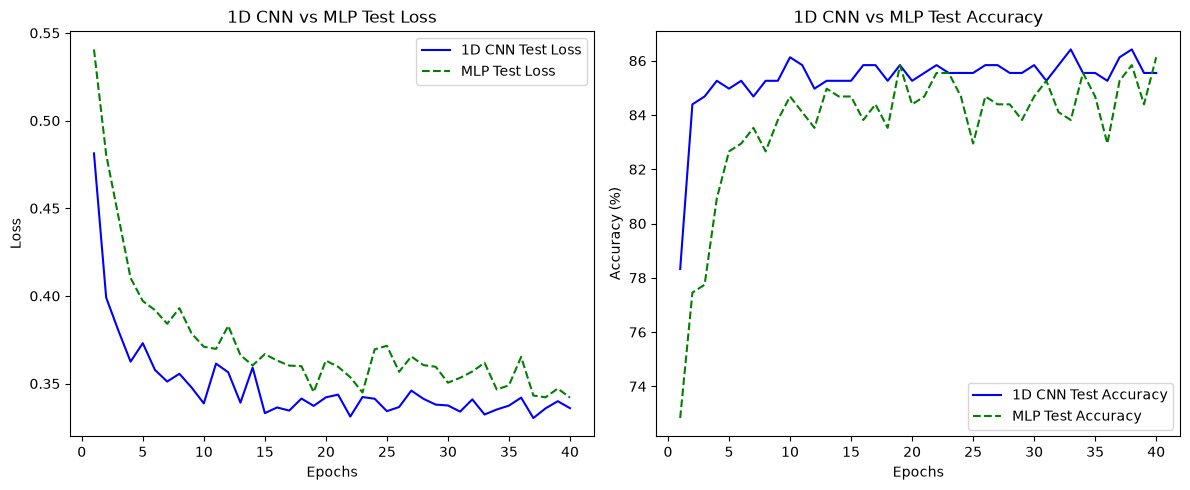

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), cnn_test_loss, label="1D CNN Test Loss", color="blue")
plt.plot(range(1, EPOCHS + 1), mlp_test_loss, label="MLP Test Loss", color="green", linestyle="--")
plt.title("1D CNN vs MLP Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), cnn_test_acc, label="1D CNN Test Accuracy", color="blue")
plt.plot(range(1, EPOCHS + 1), mlp_test_acc, label="MLP Test Accuracy", color="green", linestyle="--")
plt.title("1D CNN vs MLP Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.tight_layout()
plt.show()

## 10. Saving Best Model Weights

In [10]:
CNN_SAVE_PATH = "finger_touch_1dcnn.pth"
MLP_SAVE_PATH = "finger_touch_mlp.pth"

torch.save(model_cnn.state_dict(), CNN_SAVE_PATH)
torch.save(model_mlp.state_dict(), MLP_SAVE_PATH)
print(f"1D CNN model saved to: {CNN_SAVE_PATH}")
print(f"MLP model saved to:    {MLP_SAVE_PATH}")